In [3]:
import numpy as np
import pandas as pd
import hist
from hist import Hist
import awkward as ak
import json
import uproot
import math
from coffea import util
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import mplhep
plt.style.use(mplhep.style.CMS)

In [5]:
out_dir = "../outfiles/Run3Summer22EE/cutflow"

era = "Run3Summer22EE"
        
lumis = {
    "Run3Summer22EE" : 5111.01917163, #1000 * 19.5
}

# Table of contents <a class="anchor" id="toc"></a>

* [Plot pass/fail](#plot)

# Plot pass/fail <a class="anchor" id="plot"></a>
[TOC](#toc)

QCD (loose)
Sig eff.: 4.3 % (pass: 42269)
Z(bb) (loose)
Sig eff.: 76.7 % (pass: 356)
Z(qq) (loose)
Sig eff.: 9.8 % (pass: 287)
Data: (loose)
Sig eff.: 21.4 % (pass: 2365)


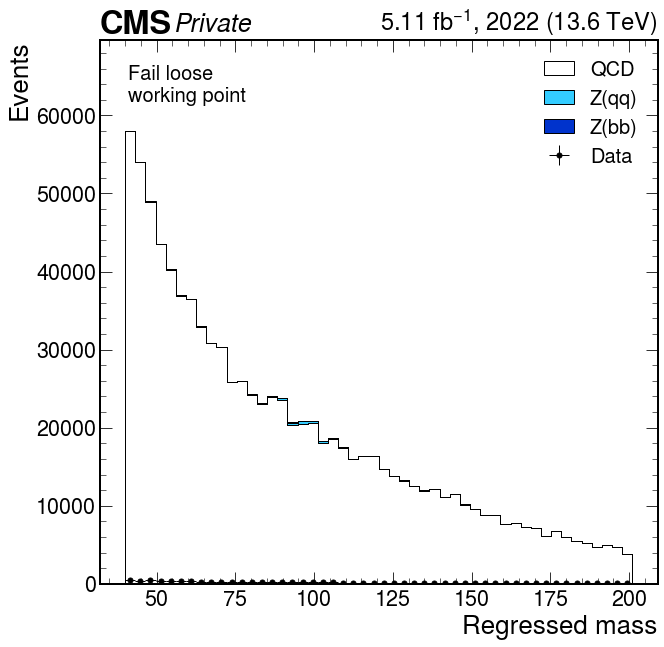

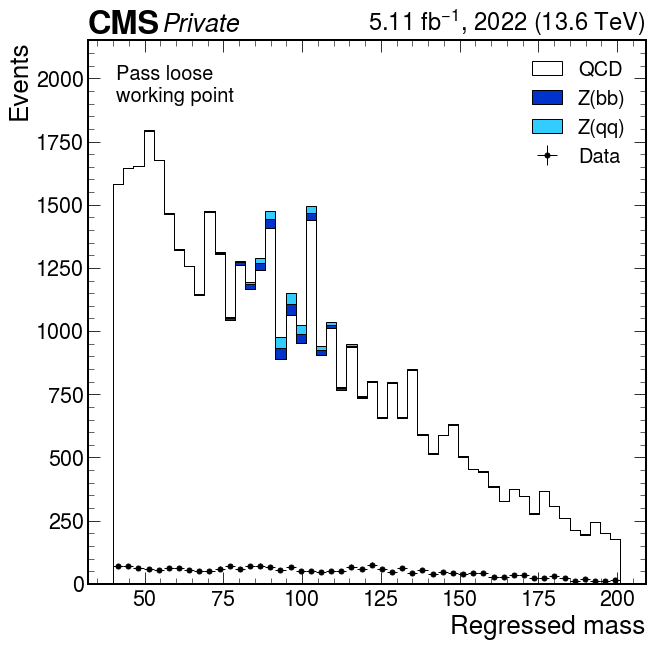

In [9]:
plt.style.use(mplhep.style.CMS)

mc = pickle.load(open(f'{out_dir}/mc.pkl','rb'))
data = pickle.load(open(f'{out_dir}/data.pkl','rb'))

colour = {
    "QCD" : "white",
    "Z(bb)" : "#0033cc",
    "Z(qq)" : "#33ccff",
#     "W" : "#cccccc",
}

wps = {
    1 : "loose",
    2 : "medium",
    3 : "tight",
}

wp = 1

for region in ["Fail", "Pass"]:
    
    hs = []
    labels = []
    colours = []
    
    fig, (ax) = plt.subplots(
        1, 1, figsize=(10, 10), #gridspec_kw={"height_ratios": (3, 1)}, sharex=True
    )
    fig.subplots_adjust(hspace=0.1)
    ax.set_ylabel("Events")
#     rax.set_ylabel("Data / MC")
#     rax.set_xlabel("Regressed mass")
#     ax.set_xlabel(" ")

    for process in colour.keys():
        
        h = mc.project("reg", "cut", "process", "disc", "genflav", "pt")
        
        if process[0] == "Z":
            if process == "Z(bb)":
                h = h[:, 5, hist.loc("ZJets"), :, 3:4:sum, 0:len:sum]
            else:
                h = h[:, 5, hist.loc("ZJets"), :, 1:3:sum, 0:len:sum]
        else:
            h = h[:, 5, hist.loc(process), :, 0:len:sum, 0:len:sum]
        
        if "Pass" in region:
            print(f"{process} ({wps[wp]})")
            print(f"Sig eff.: {h[:, wp:4:sum].sum().value/h.sum().value * 100:.1f} % (pass: {h[:, wp:4:sum].sum().value:.0f})")
            h = h[:, wp:4:sum]
#             h = h / 20
        else:
            h = h[:, 0:wp:sum]
#             h = h / 120
            
        hs.append(h)
        labels.append(process)
        colours.append(colour[process])

    mplhep.histplot(
        hs,
        ax=ax,
        label=labels,
        stack=True,
        sort="y_r",
        color=colours,
        histtype="fill",
        edgecolor="black",
        linewidth=1,
    )
    
#     ax.axvline(91, label="Z boson mass", c='red', linestyle='dashed')
        
    h = data.project("reg", "cut", "process", "disc", "genflav", "pt")[:, 5, hist.loc("Run3Summer22EE"), :, 0:len:sum, 0:len:sum]
    
    if "Pass" in region:
        print(f"Data: ({wps[wp]})")
        print(f"Sig eff.: {h[:, wp:4:sum].sum().value/h.sum().value * 100:.1f} % (pass: {h[:, wp:4:sum].sum().value:.0f})")
        h = h[:, wp:4:sum]
    else:
        h = h[:, 0:wp:sum]

    mplhep.histplot(
        h, 
        ax=ax, 
        histtype="errorbar",
        xerr=True,
        c="black",
        label=f"Data"
    )

    plt.text(0.05, 0.88, f"{region} {wps[wp]}\nworking point",
                fontsize=20,
                horizontalalignment='left',
                verticalalignment='bottom',
                transform=ax.transAxes
               )

    mplhep.cms.label(
            ax=ax, 
            data=True, 
            fontsize=25,
            label="Private",
            year=2022,
            lumi=f"{lumis[era]/1000:.2f}",
            com=13.6,
            )
    
    ax.legend(loc="upper right", fontsize=20)
    
    ax.set_ylim(0, max(hs[0].values()) * 1.2)